In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten

## Load Dataset

In [9]:
((X_train, y_train),(X_test, y_test))=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
# Checking shape
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


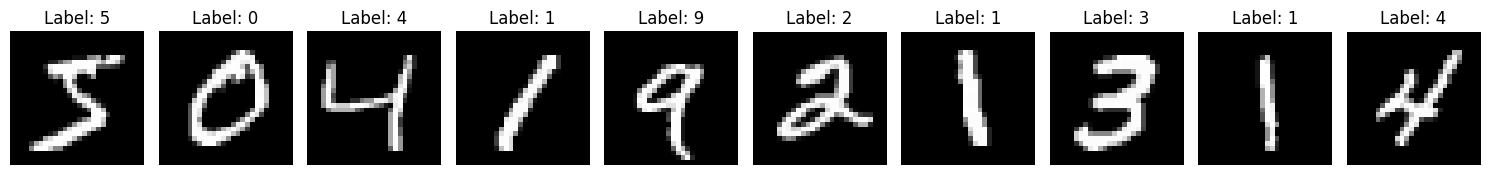

In [21]:
#visualize the data
fig, ax=plt.subplots(1,10, figsize=(15, 2))
for i in range(10):
    ax[i].imshow(X_train[i], cmap="grey")
    ax[i].set_title(f"Label: {y_train[i]}")
    ax[i].axis("off")
plt.tight_layout()
plt.show()

## Data Preprocessing

### Normalization

In [23]:
X_train=X_train/255
X_test=X_test/255

### Reshaping
- A CNN expects its input to have a **channel dimension** in addition to the image height and width.
- For datasets like **MNIST**, 1 colour channel is sufficient, but for images like **RGB**, they require <u>3 different channels per colour</u>.
- For coloured images (like RGB), the reshape would be like (28, 28, 3).

In [26]:
# -1 tells NumPy to infer the number of images automatically
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

## Defining the Architecture of CNN Model

In [32]:
model=Sequential()

model.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(28,28,1), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(filters=64, kernel_size=(4,4), input_shape=(28,28,1), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
# model.add(Dropout=0.5)
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783784062.094347      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,866 (647.91 KB)

 Trainable params: 165,866 (647.91 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [36]:
hist_model1=model.fit(X_train,y_train,batch_size=32,epochs=10,verbose=1,validation_split=0.2)

Epoch 1/10
  62/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4714 - loss: 1.6232

I0000 00:00:1783784974.141623     549 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9548 - loss: 0.1472 - val_accuracy: 0.9816 - val_loss: 0.0598
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9855 - loss: 0.0475 - val_accuracy: 0.9873 - val_loss: 0.0461
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9895 - loss: 0.0329 - val_accuracy: 0.9886 - val_loss: 0.0417
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9926 - loss: 0.0228 - val_accuracy: 0.9895 - val_loss: 0.0373
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9945 - loss: 0.0175 - val_accuracy: 0.9898 - val_loss: 0.0383
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9956 - loss: 0.0140 - val_accuracy: 0.9900 - val_loss: 0.0417
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9958 - loss: 0.0122 - val_accuracy: 0.9900 - val_loss: 0.0436
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9969 - loss: 0.0093 - val_accurac

In [41]:
losses=pd.DataFrame(hist_model1.history)
losses

,accuracy,loss,val_accuracy,val_loss
0,0.954813,0.147151,0.981583,0.059781
1,0.985479,0.047508,0.987333,0.046148
2,0.989542,0.032867,0.988583,0.041696
3,0.992604,0.022797,0.989500,0.037296
4,0.994479,0.017500,0.989750,0.038291
5,0.995583,0.013996,0.990000,0.041717
6,0.995750,0.012158,0.990000,0.043617
7,0.996938,0.009327,0.990333,0.043023
8,0.997333,0.008204,0.988833,0.051268
9,0.997333,0.007785,0.988250,0.050907
